# 04 — Refining the headline figure
### *Rhodopseudomonas palustris* CGA009 (iAN1128) · PHB on p-coumarate

Notebook `03` builds the target list and renders the headline heatmap
(*Round-0 CRISPRi targets — after downselection*) through the locked renderer in `lib/nb71_lib.py`.
**This notebook refines that figure without touching `nb71_lib`.** It imports only the *data*
(`nb71_lib.get_data()` — which just reads the NB60–64 result CSVs + the curated AI table) and
re-implements the renderer inline as `heatmap_v2()`, so the figure can be iterated freely.

**v1 changes (this pass):**

| # | Request | How |
|---|---|---|
| 1 | **Remove the title** | `heatmap_v2` never calls `set_title` |
| 2 | **y-labels = shorthand gene name only** (e.g. `phaR`) | new `short` column: curated symbol where one exists, else a conventional enzyme symbol (`EXTRA_SYMBOLS`), else the RPA locus |
| 3 | **all y-labels solid black** | tick labels forced to `black`, normal weight (the old per-source colour/bold encoding is dropped) |

**Every gene name is cross-validated against the CGA009 RefSeq annotation** (assembly `GCF_000195775.1`)
and UniProt (Part 1). That check turned up real errors in the upstream AI-prediction table — two mislabelled
symbols (`accA`→`accD`, `sdhA`→`sdhB`) and **seven regulator rows whose RPA locus points at an unrelated
gene** (`phaZ`, `phaR`, `glnB`, `glnK`, `ntrB`, `nifA`, `regB`); those corrections are in **Part 1b**.

Outputs are written with a **new `nb04_` prefix** so the NB03 figure (`nb71_downselected.*`) is never
overwritten. Everything downstream of the figure (the roadmap for alternative encodings) is in Part 3.

## Part 0 · Load the data and apply the downselection

`nb71_lib.get_data()` rebuilds the combined **51-target** FBA+AI table (identical to NB03 Part 5) and, as a
side effect, populates `nb71_lib._STATE` with the per-method cell-intensity maps (`gmraw`, `gmmag`) the
renderer needs. We then apply the same 10-gene literature cut list NB03 uses to reach the **41 kept**
targets. (The cut set is reproduced here as a literal so this notebook is self-contained; it matches
`GROUPS_TO_APPLY` in NB03.)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "lib")); sys.path.insert(0, str(Path.cwd().parent / "lib" / "FluxRETAP"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nb60_lib as L, nb71_lib as NB
pd.set_option("display.width", 260); pd.set_option("display.max_colwidth", 60)

rows, ai = NB.get_data()                 # 51-target combined table; also populates NB._STATE (gmraw/gmmag)

# the 10 loci NB03 cuts (regulators are deliberately KEPT) -> 41 remain. See NB03 Part 5 CUT_LIBRARY.
CUTS = {"RPA4566",  # ackA   (redundant duplicate)
        "RPA0426",  # fabH   (redundant duplicate)
        "RPA2019",  # fabF   (redundant duplicate)
        "RPA4394",  # isocitrate lyase (counter-evidence)
        "RPA0670",  # hbaA   (counter-evidence)
        "RPA2967",  # glnA   (single-guide-infeasible, isozyme redundancy)
        "RPA0891",  # gltB   (N-sensor, metabolic)
        "RPA4180",  # pntA   (high-risk metabolic)
        "RPA2937",  # nuoF   (high-risk metabolic)
        "RPA0175"}  # atpA   (high-risk metabolic)
df = rows[~rows.gene.isin(CUTS)].reset_index(drop=True)
print(f"combined {len(rows)} -> downselected {len(df)} kept  |  sources: {df.source.value_counts().to_dict()}")

combined 51 -> downselected 41 kept  |  sources: {'FBA': 23, 'AI': 9, 'FBA+AI': 6, 'AI+FBA': 3}


## Part 1 · Shorthand gene names for the y-axis (cross-validated against NCBI RefSeq)

Every symbol below was **cross-validated against the CGA009 RefSeq annotation** (assembly
`GCF_000195775.1`, chromosome `NC_005296.1`) and UniProt (taxid 258594). Two maps:

- **`EXTRA_SYMBOLS`** — the FBA-only loci, which the iAN1128 model stores as bare `RPA####` tags. Symbols
  that RefSeq/UniProt assign by name are marked `NCBI`/`UniProt`; the rest are the **conventional symbol for
  the annotated enzyme** and marked `conv` (function-confirmed by the RefSeq product, but RefSeq assigns no
  symbol). One locus (`RPA0818`) is left as its tag — RefSeq calls it a 3-hydroxyacyl-CoA dehydrogenase with
  no clean symbol.
- **`SYMBOL_FIX`** — two AI-table symbols that were **wrong for their locus** and are corrected here:
  `RPA0071` is **accD** (carboxyl-transferase β), not accA; `RPA0216` is **sdhB** (the Fe-S subunit) — the
  true `sdhA` flavoprotein is `RPA0217`.

The deeper problem — several AI-table rows whose **locus points at an unrelated gene** — is handled
separately in **Part 1b**, because it changes the target *loci*, not these display labels.

`short_name()` order: **`SYMBOL_FIX` → curated `ai_symbol` → `EXTRA_SYMBOLS` → RPA locus.**

In [2]:
# FBA-only loci -> gene symbol. src tag: NCBI = RefSeq gene= symbol; UniProt = UniProt primary; conv =
# conventional symbol for the RefSeq-annotated enzyme (RefSeq assigns no symbol, but the product confirms it).
EXTRA_SYMBOLS = {
    "RPA0411": "ppa",    # NCBI  inorganic diphosphatase
    "RPA3056": "ndk",    # NCBI  nucleoside-diphosphate kinase
    "RPA1051": "ppdK",   # NCBI  pyruvate, phosphate dikinase
    "RPA1331": "mqo",    # NCBI  malate:quinone oxidoreductase
    "RPA1580": "putA",   # NCBI  proline dehydrogenase/P5C dehydrogenase (bifunctional)
    "RPA3815": "rpe",    # NCBI  ribulose-phosphate 3-epimerase
    "RPA3636": "zwf",    # NCBI  glucose-6-phosphate dehydrogenase
    "RPA4410": "glpD",   # NCBI  glycerol-3-phosphate dehydrogenase
    "RPA0163": "proB",   # NCBI  glutamate 5-kinase
    "RPA4211": "glsA",   # UniProt glutaminase
    "RPA0360": "pckA",   # UniProt PEP carboxykinase (ATP)
    "RPA4721": "por",    # conv  2-oxoacid:acceptor oxidoreductase (pyruvate:ferredoxin oxidoreductase)
    "RPA3229": "adk",    # conv  adenylate kinase
    "RPA1578": "fpr",    # conv  ferredoxin--NADP reductase
    "RPA3042": "maeB",   # conv  NADP-dependent malic enzyme
    "RPA0822": "gshA",   # conv  glutamate--cysteine ligase
    "RPA3634": "pgi",    # conv  bifunctional transaldolase/phosphoglucose isomerase (pgi activity)
    # --- newly identified from the RefSeq product (were shown as loci in v1) ---
    "RPA3173": "acyP",   # UniProt acylphosphatase (hydrolyses 1,3-BPG -> matches model rxn R01515)
    "RPA4727": "glgP",   # conv  glycogen/starch/alpha-glucan phosphorylase
    "RPA3450": "mmsA",   # conv  CoA-acylating methylmalonate-semialdehyde dehydrogenase
    "RPA0560": "mcd",    # UniProt MLYCD; malonyl-CoA decarboxylase
    "RPA0962": "hupS",   # conv  uptake hydrogenase small subunit (provisional; hup vs hox)
    # RPA0818 left as its locus: RefSeq = 3-hydroxyacyl-CoA dehydrogenase, no clean symbol
}
# AI-table symbols that were WRONG for their locus (verified vs RefSeq) -> corrected display label:
SYMBOL_FIX = {
    "RPA0071": "accD",   # was 'accA'; RPA0071 = acetyl-CoA carboxylase carboxyltransferase beta (accD)
    "RPA0216": "sdhB",   # was 'sdhA'; RPA0216 = succinate dehydrogenase Fe-S subunit (sdhB). sdhA = RPA0217
}
def short_name(r):
    """Resolve a y-axis label: SYMBOL_FIX -> curated ai_symbol -> EXTRA_SYMBOLS -> RPA locus."""
    if r.gene in SYMBOL_FIX:
        return SYMBOL_FIX[r.gene]
    if r.ai_symbol:
        return r.ai_symbol
    return EXTRA_SYMBOLS.get(r.gene, r.gene)

df["short"] = df.apply(short_name, axis=1)
_locus = df[df.short == df.gene]
print(f"labelled with a gene symbol: {len(df) - len(_locus)}/{len(df)}  |  still shown as RPA locus: {len(_locus)}")
print("  locus-only rows:", ", ".join(_locus.gene) or "(none)")
df[["gene", "short", "ai_symbol", "source", "module", "name"]]

labelled with a gene symbol: 40/41  |  still shown as RPA locus: 1
  locus-only rows: RPA0818


,gene,short,ai_symbol,source,module,name
0,RPA4721,por,,FBA,redox,pyruvate:ferredoxin 2-oxidoreductase (CoA-acetylating)
1,RPA3229,adk,,FBA,nuc,ATPAMP phosphotransferase
2,RPA2907,gltA,gltA,FBA+AI,accoa,Citrate oxaloacetate-lyase ((pro-3S)-CH2COO- - acetyl-CoA)
3,RPA4567,pta,pta,FBA+AI,accoa,acetyl-CoAphosphate acetyltransferase
4,RPA0818,RPA0818,,FBA,accoa,(S)-3-Hydroxybutanoyl-CoA 3-epimerase
5,RPA0411,ppa,,FBA,nuc,Pyrophosphate phosphohydrolase (soluble)
6,RPA1578,fpr,,FBA,redox,FerredoxinNADP+ oxidoreductase
7,RPA3056,ndk,,FBA,nuc,ATPnucleoside-diphosphate phosphatransferase
8,RPA1051,ppdK,,FBA,backbone,"ATPpyruvate,orthophosphate phosphotransferase"
9,RPA0071,accD,accA,FBA+AI,accoa,Acetyl-CoAcarbon-dioxide ligase (ADP-forming)


## Part 1b · Locus cross-validation — AI-table loci that point at the wrong gene

The AI-prediction rows in `nb71_lib` carry hand-curated `RPA####` loci for genes **not in the model**
(regulators, `phaZ`). Cross-checking each against RefSeq `GCF_000195775.1` shows **seven of them point at an
unrelated gene** — the gene *symbol* is right, but the *locus* is wrong. This matters for the wet lab: a
CRISPRi guide designed against the listed locus would repress the wrong gene. The heatmap in Part 2 shows
symbols only (so those labels are still correct), but the **corrected loci below are what to clone against**.
`LOCUS_FIX[nb71_locus] = (symbol, correct_locus, what_the_old_locus_actually_is, note)`.

In [3]:
# Verified against RefSeq GCF_000195775.1 (NC_005296.1) gene features + products, and UniProt taxid 258594.
LOCUS_FIX = {
  "RPA1786": ("phaZ", "RPA0575", "3-hydroxybutyryl-CoA dehydratase (crotonase)", "RefSeq gene=phaZ, PHA depolymerase"),
  "RPA1795": ("phaR", "RPA0530", "cation:proton antiporter",                     "RefSeq gene=phaR, PHA synthesis repressor"),
  "RPA0454": ("glnB", "RPA2966", "universal stress protein",                     "P-II regulator immediately upstream of glnA1 (RPA2967)"),
  "RPA0584": ("glnK", "RPA0272/RPA0274", "RNA-binding accessory protein",        "two P-II paralogs, each in a glnK-amtB operon (RPA0273/RPA0275 = amtB)"),
  "RPA1711": ("ntrB", "RPA2592", "nitroreductase",                               "nitrogen-regulation NR(II) sensor kinase, adjacent to ntrC (RPA2593)"),
  "RPA4630": ("nifA", "RPA4632", "NifB (nitrogenase cofactor biosynthesis)",     "RefSeq gene=nifA; RPA4630 is the neighbouring nifB"),
  "RPA3332": ("regB", "RPA0572", "curli assembly protein CsgF",                  "PrrB/RegB redox sensor kinase; RegA/PrrA = RPA0571"),
}
val = pd.DataFrame([{"symbol": s, "nb71_locus": old, "correct_locus": new,
                     "old_locus_actually_is": act, "basis": note}
                    for old, (s, new, act, note) in LOCUS_FIX.items()])
# also flag prpC: symbol correct but the locus is a pseudogene in CGA009
PSEUDO = {"RPA2394": ("prpC", "2-methylcitrate synthase — RefSeq PSEUDOGENE (partial/non-functional in CGA009)")}
val.to_csv(L.OUT / "nb04_locus_validation.csv", index=False)
print(f"AI-table loci that point at the WRONG gene: {len(val)}  (saved nb04_locus_validation.csv)")
print(f"pseudogene flag: RPA2394 = prpC is a RefSeq pseudogene -> not a viable CRISPRi target\n")
val

AI-table loci that point at the WRONG gene: 7  (saved nb04_locus_validation.csv)
pseudogene flag: RPA2394 = prpC is a RefSeq pseudogene -> not a viable CRISPRi target



,symbol,nb71_locus,correct_locus,old_locus_actually_is,basis
0,phaZ,RPA1786,RPA0575,3-hydroxybutyryl-CoA dehydratase (crotonase),"RefSeq gene=phaZ, PHA depolymerase"
1,phaR,RPA1795,RPA0530,cation:proton antiporter,"RefSeq gene=phaR, PHA synthesis repressor"
2,glnB,RPA0454,RPA2966,universal stress protein,P-II regulator immediately upstream of glnA1 (RPA2967)
3,glnK,RPA0584,RPA0272/RPA0274,RNA-binding accessory protein,"two P-II paralogs, each in a glnK-amtB operon (RPA0273/R..."
4,ntrB,RPA1711,RPA2592,nitroreductase,"nitrogen-regulation NR(II) sensor kinase, adjacent to nt..."
5,nifA,RPA4630,RPA4632,NifB (nitrogenase cofactor biosynthesis),RefSeq gene=nifA; RPA4630 is the neighbouring nifB
6,regB,RPA3332,RPA0572,curli assembly protein CsgF,PrrB/RegB redox sensor kinase; RegA/PrrA = RPA0571


## Part 2 · The refined renderer `heatmap_v2`

Structurally identical cell/side-bar drawing to `nb71_lib.heatmap` (same intensity maps, same module
ordering, same colour palette) with exactly the three v1 changes applied — see the inline `# CHANGE`
markers. `palette` reuses `nb71_lib.PALETTES` (default `"uw"` — Husky purple + gold).

In [4]:
COLS = NB.COLS              # ["FVSEOF", "FluxRETAP", "CASOP"]
MODULES = NB.MODULES        # ordered (module_key, (line1, line2)) side-bar labels

def heatmap_v2(df, fname=None, palette="uw", caption=True, ax=None, save=True):
    """Refined FBA+AI heatmap. v1 changes vs nb71_lib.heatmap:
       (1) no title; (2) y-labels = df['short'] gene names; (3) y-labels solid black, normal weight."""
    pal = NB.PALETTES[palette]; MODc = pal["mods"]
    gmraw, gmmag = NB._STATE["gmraw"], NB._STATE["gmmag"]
    d = df.copy()
    d["_bri"] = [max([gmmag[m].get(r.blue_gene, 0.0) for m in COLS]
                     + [r.ai_pred if r.ai_pred == r.ai_pred else 0.0]) for _, r in d.iterrows()]
    blocks = [(k, lab, d[d.module == k].sort_values("_bri", ascending=False))
              for k, lab in MODULES if (d.module == k).any()]
    R = pd.concat([s for _, _, s in blocks]).reset_index(drop=True)
    n = len(R); ncol = len(COLS) + 1
    V = np.full((n, ncol), np.nan); Cc = np.full((n, ncol), np.nan)
    for i, r in R.iterrows():
        bg = r["blue_gene"]
        for j, mth in enumerate(COLS):
            if bg in gmraw[mth]: V[i, j] = gmraw[mth][bg]; Cc[i, j] = gmmag[mth][bg]
        if r["ai_pred"] == r["ai_pred"]: V[i, len(COLS)] = r["ai_pred"]; Cc[i, len(COLS)] = r["ai_pred"]
        elif r["ai_flag"]: Cc[i, len(COLS)] = 0.10

    own = ax is None
    if own: fig, ax = plt.subplots(figsize=(9.8, max(4.5, 0.33 * n + 1.6)))
    else: fig = ax.figure

    coolcm = pal["fba"].copy(); coolcm.set_bad((0, 0, 0, 0))
    ax.imshow(np.ma.masked_invalid(np.where(np.arange(ncol) < len(COLS), Cc, np.nan)),
              cmap=coolcm, vmin=0, vmax=1, aspect="auto")
    warmcm = pal["ai"].copy(); warmcm.set_bad((0, 0, 0, 0))
    so = np.full((n, ncol), np.nan); so[:, len(COLS)] = Cc[:, len(COLS)]
    ax.imshow(np.ma.masked_invalid(so), cmap=warmcm, vmin=0, vmax=1, aspect="auto")
    for i in range(n):
        for j in range(ncol):
            if not np.isnan(V[i, j]):
                ax.text(j, i, f"{V[i, j]:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if Cc[i, j] > 0.55 else "#222")
    ax.set_xticks(range(ncol)); ax.set_xticklabels(COLS + ["AI prediction\n(norm. score)"], fontsize=9)

    # --- CHANGE 2: y-labels = shorthand gene name (df['short']) ---
    ax.set_yticks(range(n)); ax.set_yticklabels(R.short, fontsize=7.6)
    # --- CHANGE 3: all y-labels solid black, normal weight (drop per-source colour + bold) ---
    for lbl in ax.get_yticklabels():
        lbl.set_color("black"); lbl.set_fontweight("normal")

    for x in range(1, ncol): ax.axvline(x - 0.5, color="white", lw=2.5)
    ax.axvline(len(COLS) - 0.5, color="#888", lw=2.5); ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)

    xbar = ncol - 0.5 + 0.16; xtxt = ncol - 0.5 + 0.42; y0 = 0
    for key, (t1, t2), sub in blocks:
        y1 = y0 + len(sub) - 1
        ax.plot([xbar, xbar], [y0 - 0.32, y1 + 0.32], color=MODc[key], lw=6.5,
                solid_capstyle="round", clip_on=False)
        ym = (y0 + y1) / 2.0
        ax.text(xtxt, ym - (0.18 if t2 else 0), t1, color=MODc[key], fontsize=9.4,
                fontweight="bold", va="center", ha="left", clip_on=False)
        if t2: ax.text(xtxt, ym + 0.42, t2, color="#6b6b6b", fontsize=8.0, va="center", ha="left", clip_on=False)
        ax.axhline(y1 + 0.5, color="#ededed", lw=1.0); y0 = y1 + 1

    # --- CHANGE 1: no title (set_title deliberately omitted) ---
    if caption:
        ax.text(0.0, 1.0 + 0.5 / max(n, 8),
                "Cells: blue = FBA within-method strength (gene-level, per method)  ·  "
                "orange = AI literature-prior score (0-1)",
                transform=ax.transAxes, ha="left", va="bottom", fontsize=6.8, style="italic", color="#777")
    if own and save and fname:
        for ext in ("png", "svg"):
            fig.savefig(L.FIG / f"{fname}.{ext}", bbox_inches="tight", dpi=170,
                        transparent=False, facecolor="white")
        print(f"saved {L.FIG / (fname + '.png')}  (+ .svg)")
    print(f"rendered {fname or '<inline>'} ({n} genes)")
    return fig

## Part 2b · Render the refined figure (41 kept)

Written to `Results/nb60_targets/figures/nb04_downselected_refined.{png,svg}` — a **new** file; the NB03
headline (`nb71_downselected.*`) is left untouched.

saved C:\Users\jscom\OneDrive\Documents\CGA009_GSM\Release_github\Results\nb60_targets\figures\nb04_downselected_refined.png  (+ .svg)
rendered nb04_downselected_refined (41 genes)


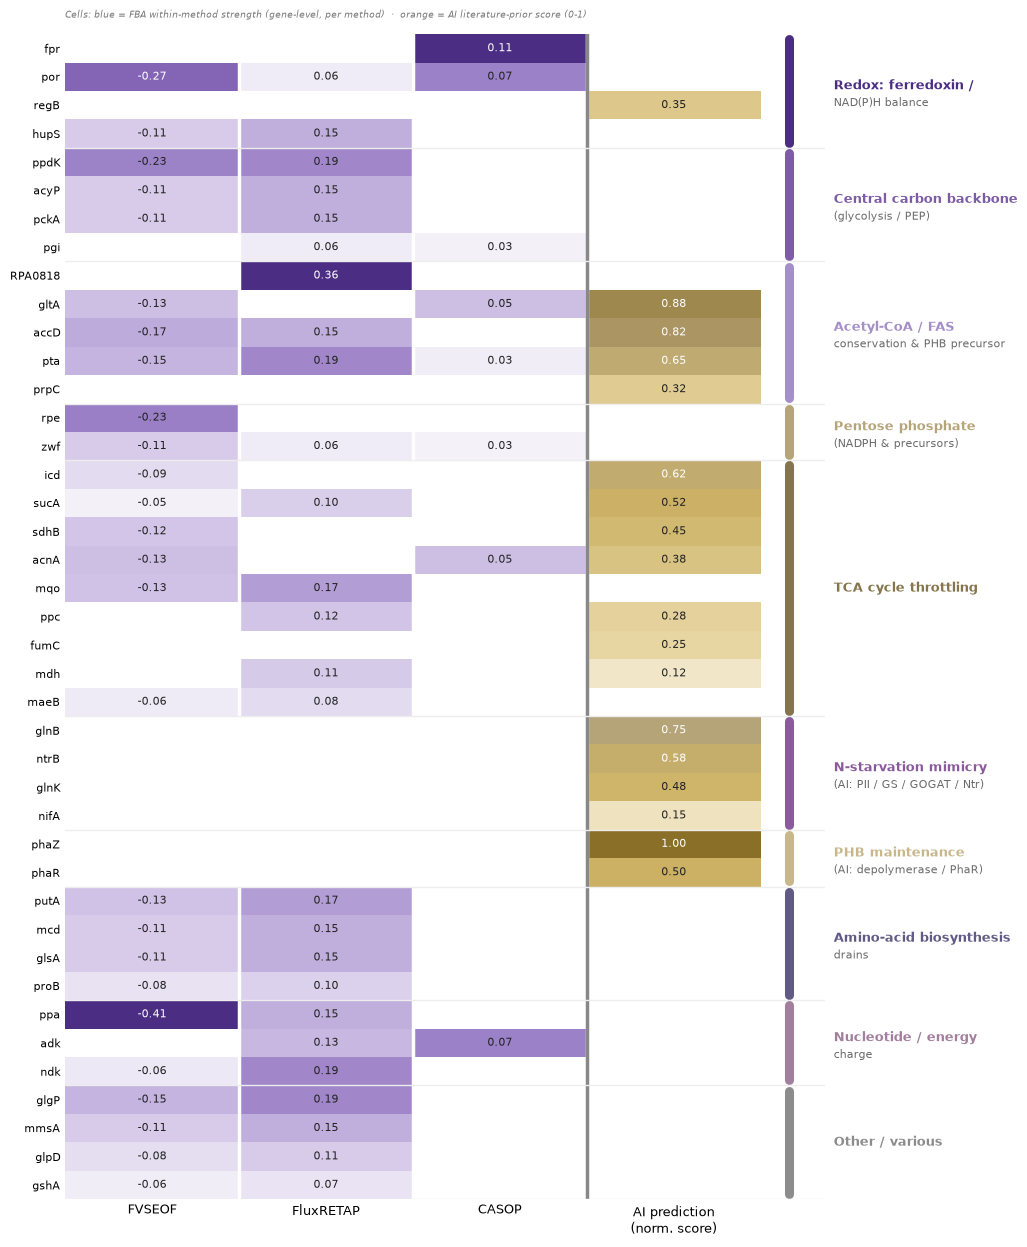

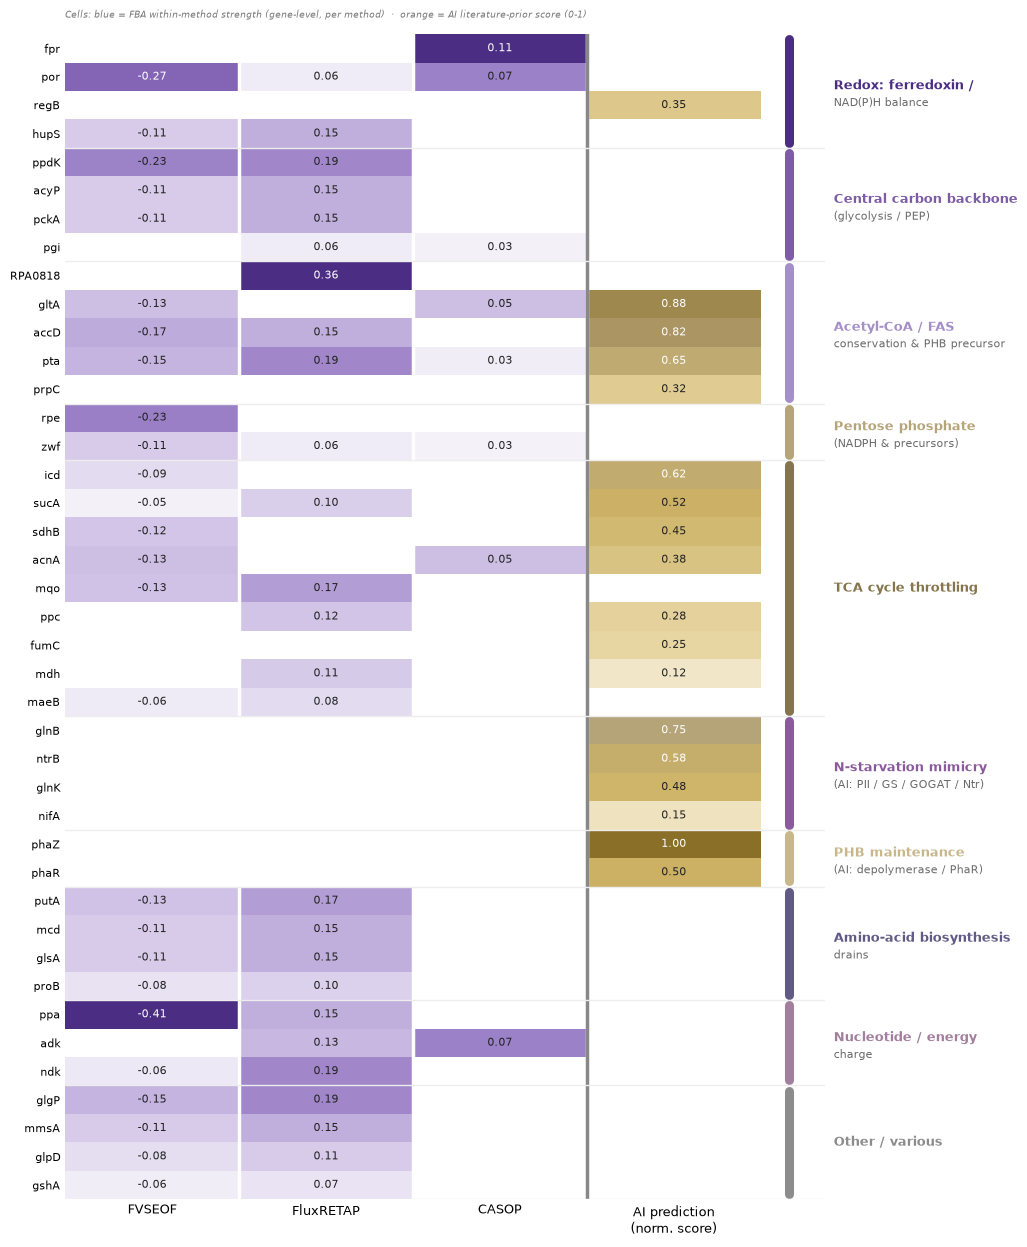

In [5]:
heatmap_v2(df, "nb04_downselected_refined", palette="uw")

## Part 3 · Roadmap — alternative ways to portray this data

The heatmap answers *"which method(s) flagged each gene, and how strongly"* but has weaknesses worth
prototyping alternatives against:

- **Two incomparable colour scales** (FBA within-method strength vs AI prior) sit side by side and invite a
  false apples-to-apples read; the FBA cells are *within-method ranks*, not cross-method-comparable.
- **Empty cells are ambiguous** — "not flagged by this method" vs "flagged but near-zero" look similar.
- **Source structure** (FBA-only / FBA+AI consensus / AI-only) is no longer encoded now that labels are
  uniform black — a candidate to re-add as a small glyph or a left-edge marker if wanted.

Candidate encodings to try next (each its own cell/function, same 41-gene frame):

1. **Method-support dot matrix** — a dot per (gene × method), size = |score|, colour = method family; makes
   "how many methods" and consensus pop, and sidesteps the two-colour-scale problem.
2. **Diverging consensus bar** — one bar per gene: FBA consensus score left, AI prior right, so the two
   evidence streams are visually separated and rank-ordered.
3. **Grouped small-multiples** — one mini-panel per module, genes ranked within; foregrounds the biological
   strategy over the flat 41-row list.
4. **Evidence scatter** — x = FBA consensus, y = AI prior, marker = source; the top-right quadrant is the
   double-supported set at a glance.

These are intentionally left as stubs — this pass locks the refined heatmap first.